In [ ]:
# ============================================================
# HYDROTERRA - PHASE 1
# Nishita's Terrain Generation Notebook
# ============================================================
#
# This cell connects Google Colab to our shared Google Drive.
# All project files are stored directly inside the HydroTerra
# Google Drive folder so that both teammates can access them.
# ============================================================

from google.colab import drive

# Mount Google Drive to the Colab environment.
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# PROJECT PATH
# ============================================================

# We keep one central path so that we don't have to repeatedly
# type the entire Google Drive location throughout the notebook.

PROJECT_PATH = "/content/drive/MyDrive/TerraFlow CG project"
print("HydroTerra project path:")
print(PROJECT_PATH)

HydroTerra project path:
/content/drive/MyDrive/TerraFlow CG project


In [ ]:
import os

project_folder = "/content/drive/MyDrive/TerraFlow CG project"

print(os.listdir(project_folder))

['notebooks', 'src', 'pygame_app', 'data', 'outputs']


In [ ]:
# ============================================================
# CHECK PROJECT STRUCTURE
# ============================================================


folders = [
    "data",
    "notebooks",
    "outputs",
    "pygame_app",
    "src"
]

for folder in folders:
    folder_path = os.path.join(PROJECT_PATH, folder)

    if os.path.exists(folder_path):
        print(f"✓ {folder}/ exists")
    else:
        print(f"✗ {folder}/ is missing")

✓ data/ exists
✓ notebooks/ exists
✓ outputs/ exists
✓ pygame_app/ exists
✓ src/ exists


In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# TERRAIN SETTINGS
# ============================================================

# 128 x 128 is our initial terrain resolution.
#
# We deliberately start small because:
# 1. It is fast to calculate.
# 2. It is enough to demonstrate the concept.
# 3. Our laptops are not extremely powerful.
# 4. We can later test 256 x 256 if performance allows.

TERRAIN_SIZE = 128

print(f"Terrain resolution: {TERRAIN_SIZE} x {TERRAIN_SIZE}")
print(f"Total terrain cells: {TERRAIN_SIZE * TERRAIN_SIZE}")

Terrain resolution: 128 x 128
Total terrain cells: 16384


In [ ]:
# ============================================================
# BASIC TERRAIN TEST
# ============================================================

# Create an empty 128 x 128 array.
heightmap = np.zeros((TERRAIN_SIZE, TERRAIN_SIZE))

# Create coordinate arrays.
x = np.linspace(-3, 3, TERRAIN_SIZE)
y = np.linspace(-3, 3, TERRAIN_SIZE)

# Create a 2D coordinate grid.
X, Y = np.meshgrid(x, y)

# Create a simple hill using a Gaussian-like function.
heightmap = np.exp(-(X**2 + Y**2))

print("Heightmap shape:", heightmap.shape)
print("Minimum height:", heightmap.min())
print("Maximum height:", heightmap.max())

Heightmap shape: (128, 128)
Minimum height: 1.522997974471263e-08
Maximum height: 0.9988846202668948


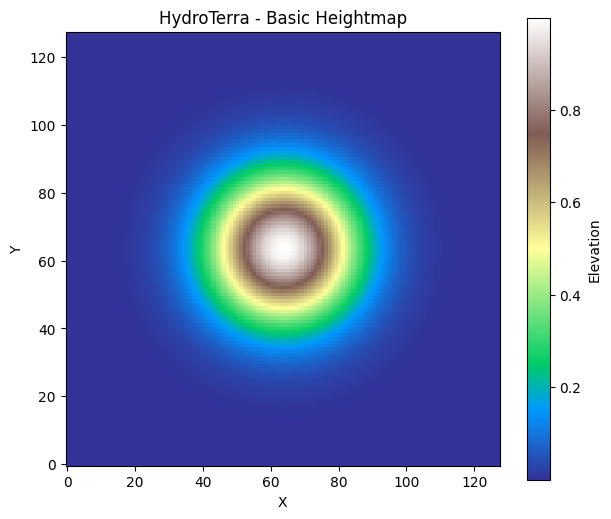

In [ ]:
# ============================================================
# DISPLAY HEIGHTMAP
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    heightmap,
    cmap="terrain",
    origin="lower"
)

plt.colorbar(label="Elevation")
plt.title("HydroTerra - Basic Heightmap")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [ ]:
!pip install noise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for noise: filename=noise-1.2.2-cp313-cp313-linux_x86_64.whl size=56718 sha256=9e7e12f88cfc227d63cef9c39646c52ed380c8745adfc50922f2a28249aa9da0
  Stored in directory: /root/.cache/pip/wheels/6a/4c/99/fe9adf3dca70780d28cf2e24e63a11fee02bdbe5d9931d3c38
Successfully built noise


In [ ]:
from noise import pnoise2

print("Noise library loaded.")

Noise library loaded.


In [ ]:
# ============================================================
# PROCEDURAL TERRAIN GENERATOR
# ============================================================

def generate_terrain(size=128, scale=50.0, octaves=5):
    """
    Generate a procedural terrain heightmap using Perlin noise.

    Parameters
    ----------
    size : int
        Number of cells along each dimension.
        For our MVP we use 128 x 128.

    scale : float
        Controls how stretched/smooth the terrain is.

    octaves : int
        Number of layers of noise combined together.
        More octaves = more small-scale terrain detail.

    Returns
    -------
    numpy.ndarray
        A normalized heightmap with values between 0 and 1.
    """

    # Create an empty 2D array to store terrain heights.
    terrain = np.zeros((size, size), dtype=np.float32)

    # Generate noise values for every grid cell.
    for y in range(size):
        for x in range(size):

            # Convert the grid coordinates into noise coordinates.
            # Dividing by scale controls the size of terrain features.
            nx = x / scale
            ny = y / scale

            # pnoise2 generates a Perlin-noise value.
            value = pnoise2(
                nx,
                ny,
                octaves=octaves,
                persistence=0.5,
                lacunarity=2.0,
                repeatx=size,
                repeaty=size,
                base=42
            )

            terrain[y, x] = value

    # --------------------------------------------------------
    # NORMALIZATION
    # --------------------------------------------------------
    #
    # Perlin noise does not naturally give us exactly 0 to 1.
    # We normalize the values so that:
    #
    # minimum terrain height = 0
    # maximum terrain height = 1
    #
    # This makes later rendering and simulation easier.

    terrain_min = terrain.min()
    terrain_max = terrain.max()

    terrain = (terrain - terrain_min) / (
        terrain_max - terrain_min
    )

    return terrain

In [ ]:
# ============================================================
# GENERATE HYDROTERRA TERRAIN
# ============================================================

heightmap = generate_terrain(
    size=128,
    scale=50.0,
    octaves=5
)

print("Terrain generated!")
print("Shape:", heightmap.shape)
print("Minimum:", heightmap.min())
print("Maximum:", heightmap.max())

Terrain generated!
Shape: (128, 128)
Minimum: 0.0
Maximum: 1.0


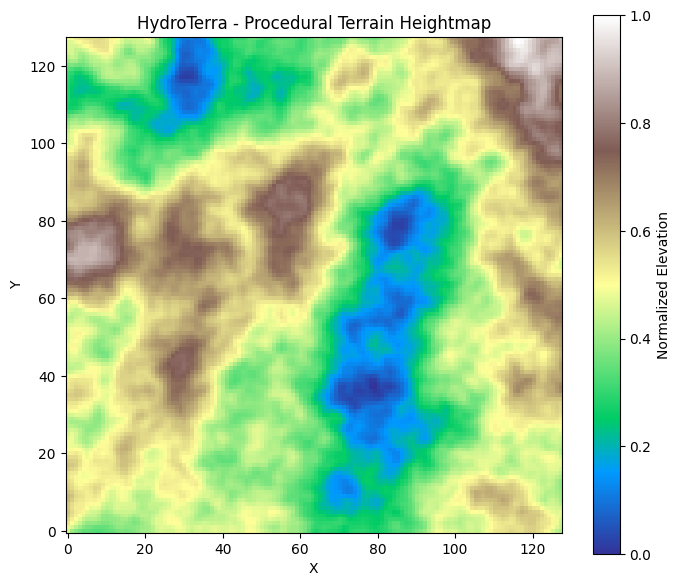

In [ ]:
# ============================================================
# 2D TERRAIN VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 7))

plt.imshow(
    heightmap,
    cmap="terrain",
    origin="lower"
)

plt.colorbar(label="Normalized Elevation")

plt.title("HydroTerra - Procedural Terrain Heightmap")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [ ]:
# ============================================================
# CREATE 3D TERRAIN COORDINATES
# ============================================================

# Create X and Z coordinates for the terrain grid.
#
# We use Z for the second horizontal direction because
# Y will represent elevation in our 3D coordinate system.

x = np.arange(TERRAIN_SIZE)
z = np.arange(TERRAIN_SIZE)

X, Z = np.meshgrid(x, z)

# The heightmap becomes the Y coordinate.
Y = heightmap * 30.0

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Z shape:", Z.shape)

X shape: (128, 128)
Y shape: (128, 128)
Z shape: (128, 128)


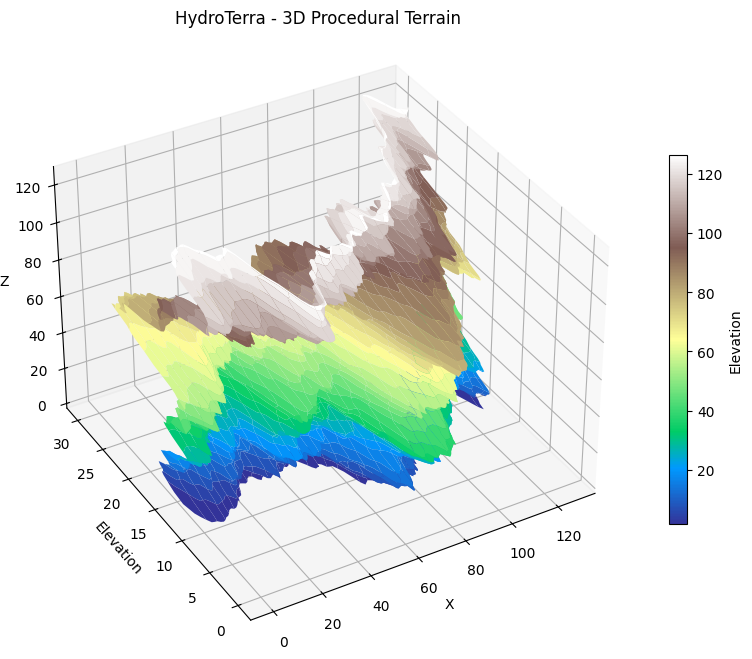

In [ ]:
# ============================================================
# 3D TERRAIN VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(11, 8))

# Create a 3D plotting area.
ax = fig.add_subplot(111, projection="3d")

# Draw the terrain surface.
surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="terrain",
    linewidth=0,
    antialiased=True
)

# Add a colorbar showing elevation.
fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Elevation"
)

# Add labels.
ax.set_title("HydroTerra - 3D Procedural Terrain")
ax.set_xlabel("X")
ax.set_ylabel("Elevation")
ax.set_zlabel("Z")

# Set a good viewing angle.
ax.view_init(
    elev=35,
    azim=-120
)

plt.show()

In [ ]:
# ============================================================
# SAVE TERRAIN DATA
# ============================================================

data_path = os.path.join(
    PROJECT_PATH,
    "data",
    "n_heightmap.npy"
)

# Save the NumPy array in binary format.
np.save(data_path, heightmap)

print("Terrain data saved to:")
print(data_path)

Terrain data saved to:
/content/drive/MyDrive/TerraFlow CG project/data/n_heightmap.npy


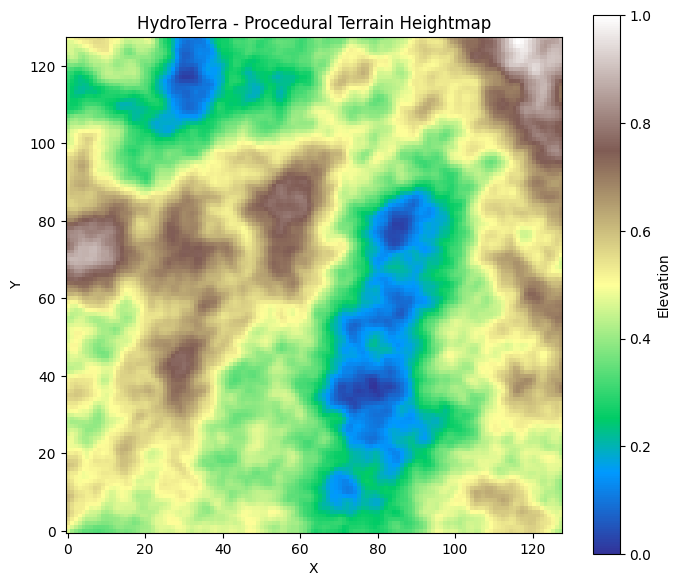

2D terrain preview saved to:
/content/drive/MyDrive/TerraFlow CG project/outputs/n_heightmap.png


In [ ]:
# ============================================================
# SAVE 2D TERRAIN PREVIEW
# ============================================================

output_path = os.path.join(
    PROJECT_PATH,
    "outputs",
    "n_heightmap.png"
)

plt.figure(figsize=(8, 7))

plt.imshow(
    heightmap,
    cmap="terrain",
    origin="lower"
)

plt.colorbar(label="Elevation")
plt.title("HydroTerra - Procedural Terrain Heightmap")
plt.xlabel("X")
plt.ylabel("Y")

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("2D terrain preview saved to:")
print(output_path)

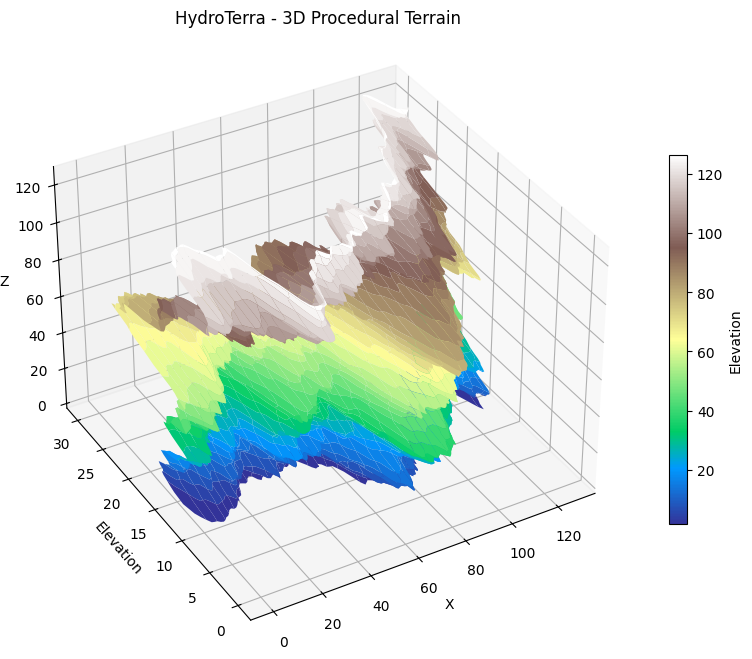

3D terrain preview saved to:
/content/drive/MyDrive/TerraFlow CG project/outputs/n_terrain_3d.png


In [ ]:
# ============================================================
# SAVE 3D TERRAIN PREVIEW
# ============================================================

output_3d_path = os.path.join(
    PROJECT_PATH,
    "outputs",
    "n_terrain_3d.png"
)

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="terrain",
    linewidth=0,
    antialiased=True
)

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Elevation"
)

ax.set_title("HydroTerra - 3D Procedural Terrain")
ax.set_xlabel("X")
ax.set_ylabel("Elevation")
ax.set_zlabel("Z")

ax.view_init(
    elev=35,
    azim=-120
)

plt.savefig(
    output_3d_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("3D terrain preview saved to:")
print(output_3d_path)

In [ ]:
# ============================================================
# TEST n_terrain.py
# ============================================================

import sys

# Add our project's src folder to Python's module search path.
SRC_PATH = os.path.join(
    PROJECT_PATH,
    "src"
)

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

# Import our own terrain module.
from n_terrain import generate_terrain

# Generate terrain.
test_terrain = generate_terrain()

print("Module imported successfully!")
print("Terrain shape:", test_terrain.shape)
print("Minimum:", test_terrain.min())
print("Maximum:", test_terrain.max())

Module imported successfully!
Terrain shape: (128, 128)
Minimum: 0.0
Maximum: 1.0


In [1]:
import sys

print("Python version:")
print(sys.version)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [2]:
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


In [3]:
!pip install pygame

In [4]:
!pip install moderngl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 2.3 MB/s eta 0:00:00


In [5]:
!pip install PyGLM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 73.6 MB/s eta 0:00:00
